<img src="../Pierian-Data-Logo.PNG">
<br>
<strong><center>Copyright 2019. Created by Jose Marcial Portilla.</center></strong>

# RNN Exercises
For these exercises we're using data from the Federal Reserve Economic Database (FRED) concerning Electricity and Gas Utilities Production from January 1992 to January 2019 (325 records).

Data source: https://fred.stlouisfed.org/series/IPG2211A2N

In the exercises below you'll be asked to do the following:
* Perform standard imports, load & plot the dataset (code provided)
* Prepare data for an LSTM model
* Define the LSTM model, loss and optimization functions
* Train the model
* Evaluate the model on test data
* OPTIONAL: Plot the results

<div class="alert alert-danger" style="margin: 10px"><strong>IMPORTANT NOTE!</strong> Make sure you don't run the cells directly above the example output shown, <br>otherwise you will end up writing over the example output!</div>

## Perform standard imports, load and plot the dataset
Run the cells below to load the libraries needed for this exercise and the Energy Production dataset, and to plot the data.

In [1]:
import torch
import torch.nn as nn

In [2]:
!nvidia-smi

Tue Jul  7 14:51:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import numpy as np
np.set_printoptions(precision=4 , suppress=True)

import pandas as pd
pd.options.display.float_format = '{:,.4f}'.format

In [5]:
import matplotlib.pyplot as plt

from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

%config InlineBackened.figure_format = 'svg'

In [6]:
from sklearn.preprocessing import MinMaxScaler

In [7]:
import datetime as dt

In [9]:
dt.datetime.now().date()

datetime.date(2026, 7, 7)

In [15]:
import pandas_datareader.data as web

series_id  = "IPG2211A2N"
start_date = '1939-01-01'
end_date = dt.datetime.now().date()

df = web.DataReader(name =  series_id,data_source = 'fred',start = start_date, end = end_date)

In [16]:
df

,IPG2211A2N
DATE,
1939-01-01,3.3336
1939-02-01,3.3591
1939-03-01,3.4354
1939-04-01,3.4608
1939-05-01,3.4608
...,...
2026-01-01,130.2919
2026-02-01,115.7332
2026-03-01,102.8251


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1049 entries, 1939-01-01 to 2026-05-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   IPG2211A2N  1049 non-null   float64
dtypes: float64(1)
memory usage: 16.4 KB


In [26]:
df.index

DatetimeIndex(['1939-01-01', '1939-02-01', '1939-03-01', '1939-04-01',
               '1939-05-01', '1939-06-01', '1939-07-01', '1939-08-01',
               '1939-09-01', '1939-10-01',
               ...
               '2025-08-01', '2025-09-01', '2025-10-01', '2025-11-01',
               '2025-12-01', '2026-01-01', '2026-02-01', '2026-03-01',
               '2026-04-01', '2026-05-01'],
              dtype='datetime64[ns]', name='DATE', length=1049, freq=None)

In [27]:
df.index.freq = "MS"

In [28]:
df.index

DatetimeIndex(['1939-01-01', '1939-02-01', '1939-03-01', '1939-04-01',
               '1939-05-01', '1939-06-01', '1939-07-01', '1939-08-01',
               '1939-09-01', '1939-10-01',
               ...
               '2025-08-01', '2025-09-01', '2025-10-01', '2025-11-01',
               '2025-12-01', '2026-01-01', '2026-02-01', '2026-03-01',
               '2026-04-01', '2026-05-01'],
              dtype='datetime64[ns]', name='DATE', length=1049, freq='MS')

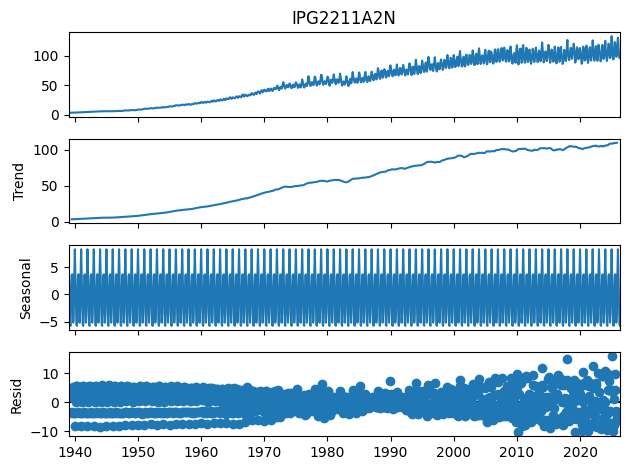

In [29]:
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['IPG2211A2N'], model='additive')
result.plot()
plt.show()

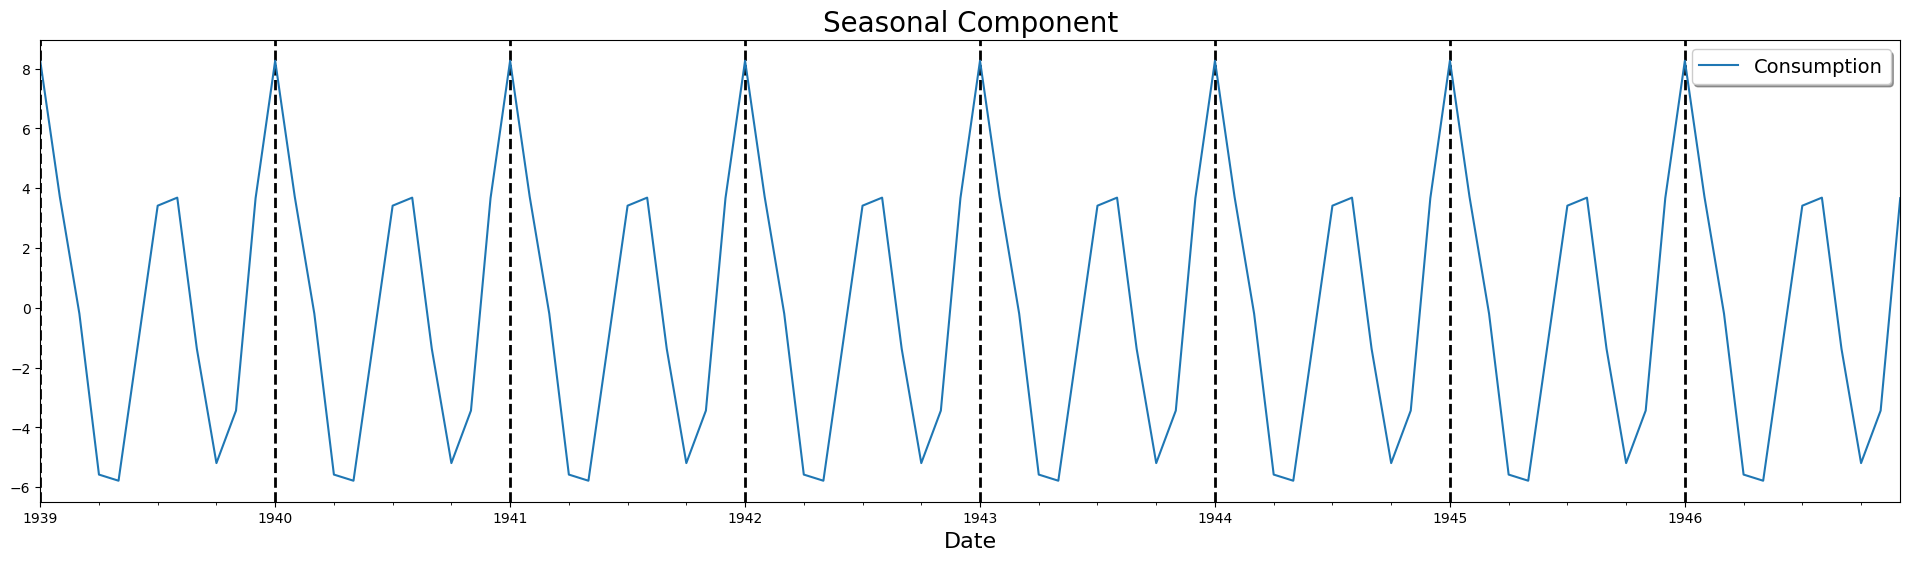

In [48]:
result.seasonal.loc["1939":"1946"].plot(figsize=(24,6))
plt.title('Seasonal Component' , fontsize = 20)
plt.xlabel('Date', fontsize = 16)
plt.grid(axis = "x" , color = "k" , ls = "--",lw = 2)
plt.legend(labels = ["Consumption" , "Seasonality"],
           fontsize=14 , 
           loc='best' , 
           frameon=True ,
           fancybox=True, 
           shadow=True, 
           ncol=1)
plt.show()

Its seasonality is 12 months, so the `window_size = 12`

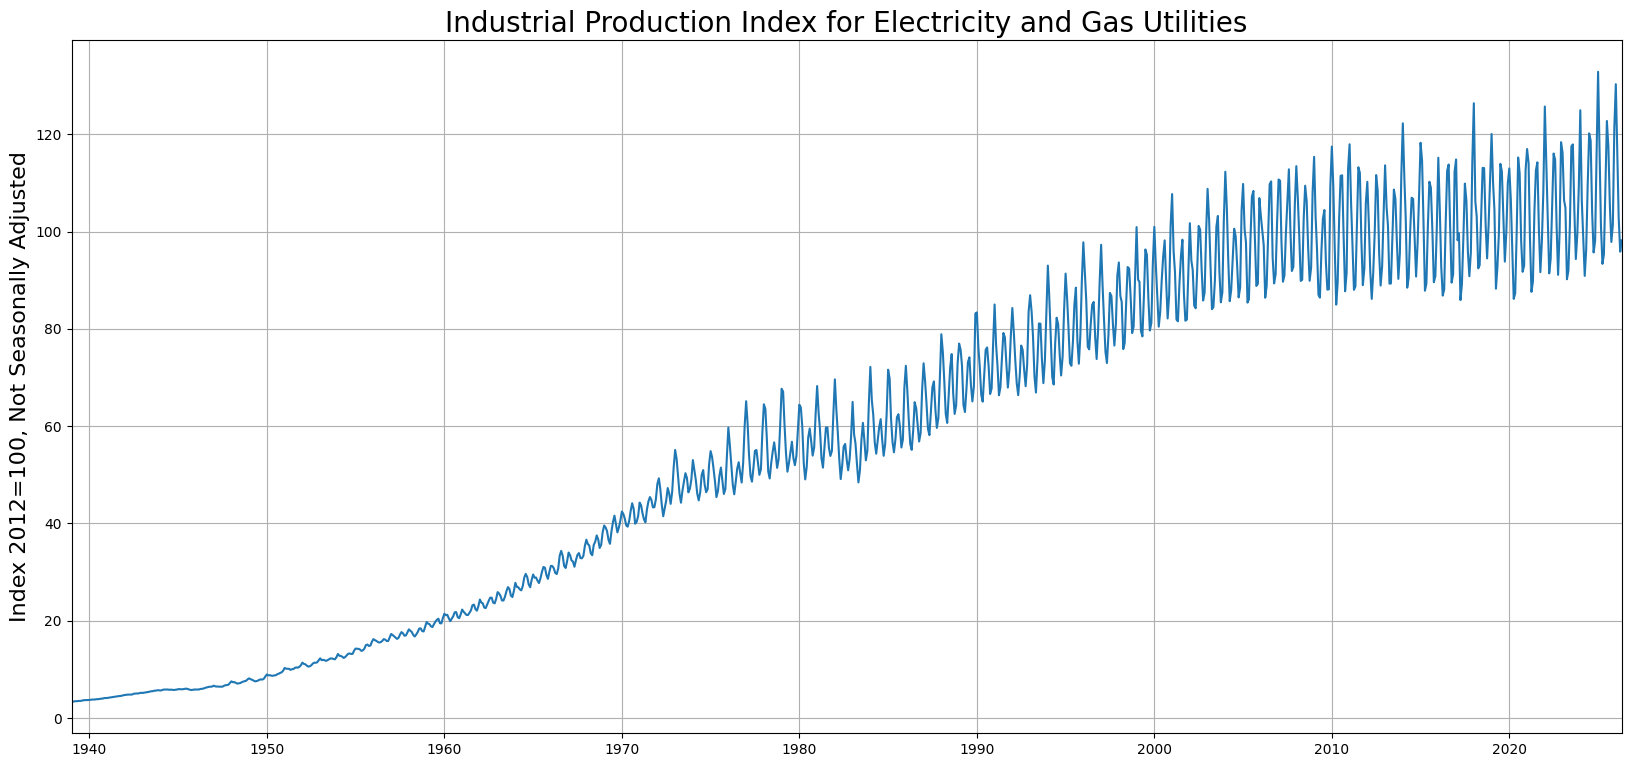

In [20]:
# RUN THIS CELL
plt.figure(figsize=(20,9))
plt.title('Industrial Production Index for Electricity and Gas Utilities' , fontsize = 20)
plt.ylabel('Index 2012=100, Not Seasonally Adjusted' , fontsize = 16)
plt.grid(True)
plt.autoscale(axis='x',tight=True)
plt.plot(df['IPG2211A2N'])
plt.show()

# Prepare the data
For the first set of exercises we'll
* divide the data into train and test sets
* normalize the training set
* prepare windowed seq/label tuples for an LSTM model

## 1. Divide the data into train and test sets
Working with a window_size of 12, divide the dataset into a sequence of 313 training records (including the window), and a test set of 12 records.

In [23]:
# CODE HERE
y = df['IPG2211A2N'].values.astype(float)
len(y)

1049

In [57]:
len(y) - 12

1037

In [58]:
test_size = 12
window_size = 12

train_set = y[:-test_size]
test_set = y[-test_size:]

In [59]:
# Run the code below to check your results:
print(f'Train: {len(train_set)}')
print(f'Test:  {len(test_set)}')
print(f'Total: {len(train_set) + len(test_set)}')

Train: 1037
Test:  12
Total: 1049


## 2. Normalize the training set
Feature scale the training set to fit within the range [-1,1].

In [60]:
scaler = MinMaxScaler(feature_range=(-1, 1))

In [61]:
train_set.reshape(-1,1)

array([[  3.3336],
       [  3.3591],
       [  3.4354],
       ...,
       [101.135 ],
       [ 93.3597],
       [ 95.3301]])

In [84]:
train_norm = scaler.fit_transform(train_set.reshape(-1,1))

In [63]:
import scipy.stats as stats

In [85]:
stats.describe(train_norm)

DescribeResult(nobs=np.int64(1037), minmax=(array([-1.]), array([1.])), mean=array([-0.1686]), variance=array([0.3112]), skewness=array([-0.0234]), kurtosis=array([-1.3496]))

In [86]:
# Run the code below to check your results:
print(f'First item, original: {train_set[0]}')
print(f'First item, scaled:  {train_norm[0]}')

First item, original: 3.3336
First item, scaled:  [-1.]


## 3. Prepare data for LSTM
Prepare the list of windowed sequence/label tuples to be fed into an LSTM model.

In [87]:
train_norm = torch.FloatTensor(train_norm).view(-1)

In [88]:
train_norm[:15]

tensor([-1.0000, -0.9996, -0.9984, -0.9980, -0.9980, -0.9972, -0.9972, -0.9965,
        -0.9949, -0.9949, -0.9945, -0.9945, -0.9941, -0.9933, -0.9929])

```python:
print(len(train_norm)) : 1037
window_size = 12
print(len(train_norm)-window_size): 1025
```

In [89]:
def input_data(seq , ws):
    Out_Put = []
    for i in range(len(seq) - ws):
        window = seq[i : i + ws]
        label = seq[i+ws:i+ws+1]
        Out_Put.append((window , label))
    return Out_Put

In [90]:
train_data = input_data(seq = train_norm , ws = 12)

In [91]:
# Run the code below to check your results:
print(f'Train_data: {len(train_data)}')  # should equal 301

Train_data: 1025


In [92]:
train_data[0]

(tensor([-1.0000, -0.9996, -0.9984, -0.9980, -0.9980, -0.9972, -0.9972, -0.9965,
         -0.9949, -0.9949, -0.9945, -0.9945]),
 tensor([-0.9941]))

## 4. Define the model
Design a model that has a (1,64) LSTM layer and a (64,1) fully-connected linear layer. Be sure to initialize $h_0$ and $c_0$, and return only the last predicted value.

In [ ]:
# CODE HERE
class LSTMnetwork(nn.Module):
    def __init__(self , input_size = 1 , hidden_size = 64 , output_size = 1):
        
        super().__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size , hidden_size)
        self.linear = nn.Linear(hidden_size ,  output_size)
        self.hidden = (torch.zeros(1,1,self.hidden_size) , torch.zeros(1,1,self.hidden_size))

    def forward(self , seq):
        lstm_out , self.hidden = self.lstm(seq.view(len(seq) , 1 , -1) , self.hidden)
        pred = self.linear(lstm_out.view(len(seq) , -1))
        return pred[-1]

In [95]:
torch.manual_seed(101)
model = LSTMnetwork()
model

LSTMnetwork(
  (lstm): LSTM(1, 64)
  (linear): Linear(in_features=64, out_features=1, bias=True)
)

In [104]:
for name , param in model.named_parameters():
    print(name ,":", len(param))
    print('\n')

lstm.weight_ih_l0 : 256


lstm.weight_hh_l0 : 256


lstm.bias_ih_l0 : 256


lstm.bias_hh_l0 : 256


linear.weight : 1


linear.bias : 1




In [105]:
parameters = [param.numel() for param in model.parameters() if param.requires_grad]
parameters

[256, 16384, 256, 256, 64, 1]

In [122]:
for p in model.named_parameters():
    if "weight" in p[0]:
        print(f"{p[0]} has size of {list(p[1].shape)}.")

lstm.weight_ih_l0 has size of [256, 1].
lstm.weight_hh_l0 has size of [256, 64].
linear.weight has size of [1, 64].


In [125]:
np.sqrt(256*64)

np.float64(128.0)

In [121]:
for param in parameters:
    print(f"{param:>6,}")
print(f"______\n{sum(parameters):>6,}")

   256
16,384
   256
   256
    64
     1
______
17,217


for param in model.pa

## 5. Define loss and optimization functions
Define a loss function called "criterion" and an optimizer called "optimizer".<br>
You can use any functions you want, although we used MSELoss and Adam (learning rate of 0.001) respectively.

In [126]:
# CODE HERE
criterion =nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters() , lr = 0.001)
model

LSTMnetwork(
  (lstm): LSTM(1, 64)
  (linear): Linear(in_features=64, out_features=1, bias=True)
)

In [8]:
# DON'T WRITE HERE

### 6. Train the model
Don't worry about tracking loss values, displaying results, or validating the test set. Just train the model through 50 epochs. We'll evaluate the trained model in the next step.<br>
OPTIONAL: print something after each epoch to indicate training progress.

In [127]:
import time

In [129]:
50%6

2

In [135]:
# CODE HERE
epochs = 50
start_time =  time.time()

for epoch in range(epochs):

    for seq ,  y_train in train_data:

        optimizer.zero_grad()
        model.hidden = (torch.zeros(1,1,model.hidden_size) , torch.zeros(1,1,model.hidden_size))

        y_pred = model(seq)
        loss  =criterion(y_pred , y_train)
        loss.backward()
        optimizer.step()

    print(f"Epoch: {epoch+1:2} of {epochs} completed /  loss:{loss.item():10.8f}")
end_time = time.time()
print(f"Duration: {(end_time - start_time)//60:.0f} minutes & {(end_time - start_time)%60:.0f} seconds.")

Epoch:  1 of 50 completed /  loss:0.00017801
Epoch:  2 of 50 completed /  loss:0.00017387
Epoch:  3 of 50 completed /  loss:0.00016950
Epoch:  4 of 50 completed /  loss:0.00016478
Epoch:  5 of 50 completed /  loss:0.00015959
Epoch:  6 of 50 completed /  loss:0.00015407
Epoch:  7 of 50 completed /  loss:0.00014823
Epoch:  8 of 50 completed /  loss:0.00014250
Epoch:  9 of 50 completed /  loss:0.00013718
Epoch: 10 of 50 completed /  loss:0.00013446
Epoch: 11 of 50 completed /  loss:0.00012781
Epoch: 12 of 50 completed /  loss:0.00012050
Epoch: 13 of 50 completed /  loss:0.00011472
Epoch: 14 of 50 completed /  loss:0.00011057
Epoch: 15 of 50 completed /  loss:0.00010811
Epoch: 16 of 50 completed /  loss:0.00010527
Epoch: 17 of 50 completed /  loss:0.00010660
Epoch: 18 of 50 completed /  loss:0.00010609
Epoch: 19 of 50 completed /  loss:0.00011200
Epoch: 20 of 50 completed /  loss:0.00011381
Epoch: 21 of 50 completed /  loss:0.00012238
Epoch: 22 of 50 completed /  loss:0.00013045
Epoch: 23 

### 9. Evaluate the model using the test set
Be sure to re-initialize the hidden parameters $h_0$ and $c_0$ before running the model.

In [140]:
window_size = 12

In [144]:
train_norm[-window_size:].tolist()

[0.6401005387306213,
 0.8044683933258057,
 0.7816345691680908,
 0.5522521734237671,
 0.42635250091552734,
 0.4631575345993042,
 0.7381597757339478,
 1.0,
 0.7486053109169006,
 0.5103355646133423,
 0.3902624845504761,
 0.4206911325454712]

In [145]:
# CODE HERE
future = 12
preds = train_norm[:-window_size].tolist()

model.eval()

for i in range(future):

    seq = torch.FloatTensor(preds[-window_size:])
    with torch.no_grad():
        model.hidden = (torch.zeros(1,1,model.hidden_size) , torch.zeros(1,1,model.hidden_size))
        preds.append(model(seq).item())

In [239]:
# Run the code below to check your results:
preds[-window_size:]

[0.6563373804092407,
 0.8337271809577942,
 0.748573362827301,
 0.5405876040458679,
 0.39645734429359436,
 0.49972444772720337,
 0.75884610414505,
 0.8889668583869934,
 0.6725786924362183,
 0.5334855914115906,
 0.37788331508636475,
 0.4501626491546631]

## 10. Inverse transform the predicted values
Rescale the predicted values up to the original test set range.

In [147]:
np.array(preds[window_size:])

array([-0.9941, -0.9933, -0.9929, ...,  0.5335,  0.3779,  0.4502])

In [148]:
np.array(preds[window_size:]).reshape(-1, 1)

array([[-0.9941],
       [-0.9933],
       [-0.9929],
       ...,
       [ 0.5335],
       [ 0.3779],
       [ 0.4502]])

In [200]:
# CODE HERE
true_predictions = scaler.inverse_transform(np.array(preds[-window_size:]).reshape(-1, 1))

In [201]:
# Run the code below to check your results:
true_predictions

array([[110.5893],
       [122.0761],
       [116.562 ],
       [103.094 ],
       [ 93.7608],
       [100.4479],
       [117.2272],
       [125.6532],
       [111.641 ],
       [102.6341],
       [ 92.5581],
       [ 97.2385]])

In [202]:
df["IPG2211A2N"]

,IPG2211A2N
DATE,
1939-01-01,3.3336
1939-02-01,3.3591
1939-03-01,3.4354
1939-04-01,3.4608
1939-05-01,3.4608
...,...
2026-01-01,130.2919
2026-02-01,115.7332
2026-03-01,102.8251


In [203]:
## BONUS EXERCISE: Plot the result
start_time_date = df[-12:].index[0].strftime("%Y-%m-%d")
end_time_date = df[-12:].index[-1].strftime("%Y-%m-%d")

In [204]:
x = pd.date_range(start=start_time_date, end=end_time_date, freq='MS')

In [205]:
# CODE HERE
x

DatetimeIndex(['2025-06-01', '2025-07-01', '2025-08-01', '2025-09-01',
               '2025-10-01', '2025-11-01', '2025-12-01', '2026-01-01',
               '2026-02-01', '2026-03-01', '2026-04-01', '2026-05-01'],
              dtype='datetime64[ns]', freq='MS')

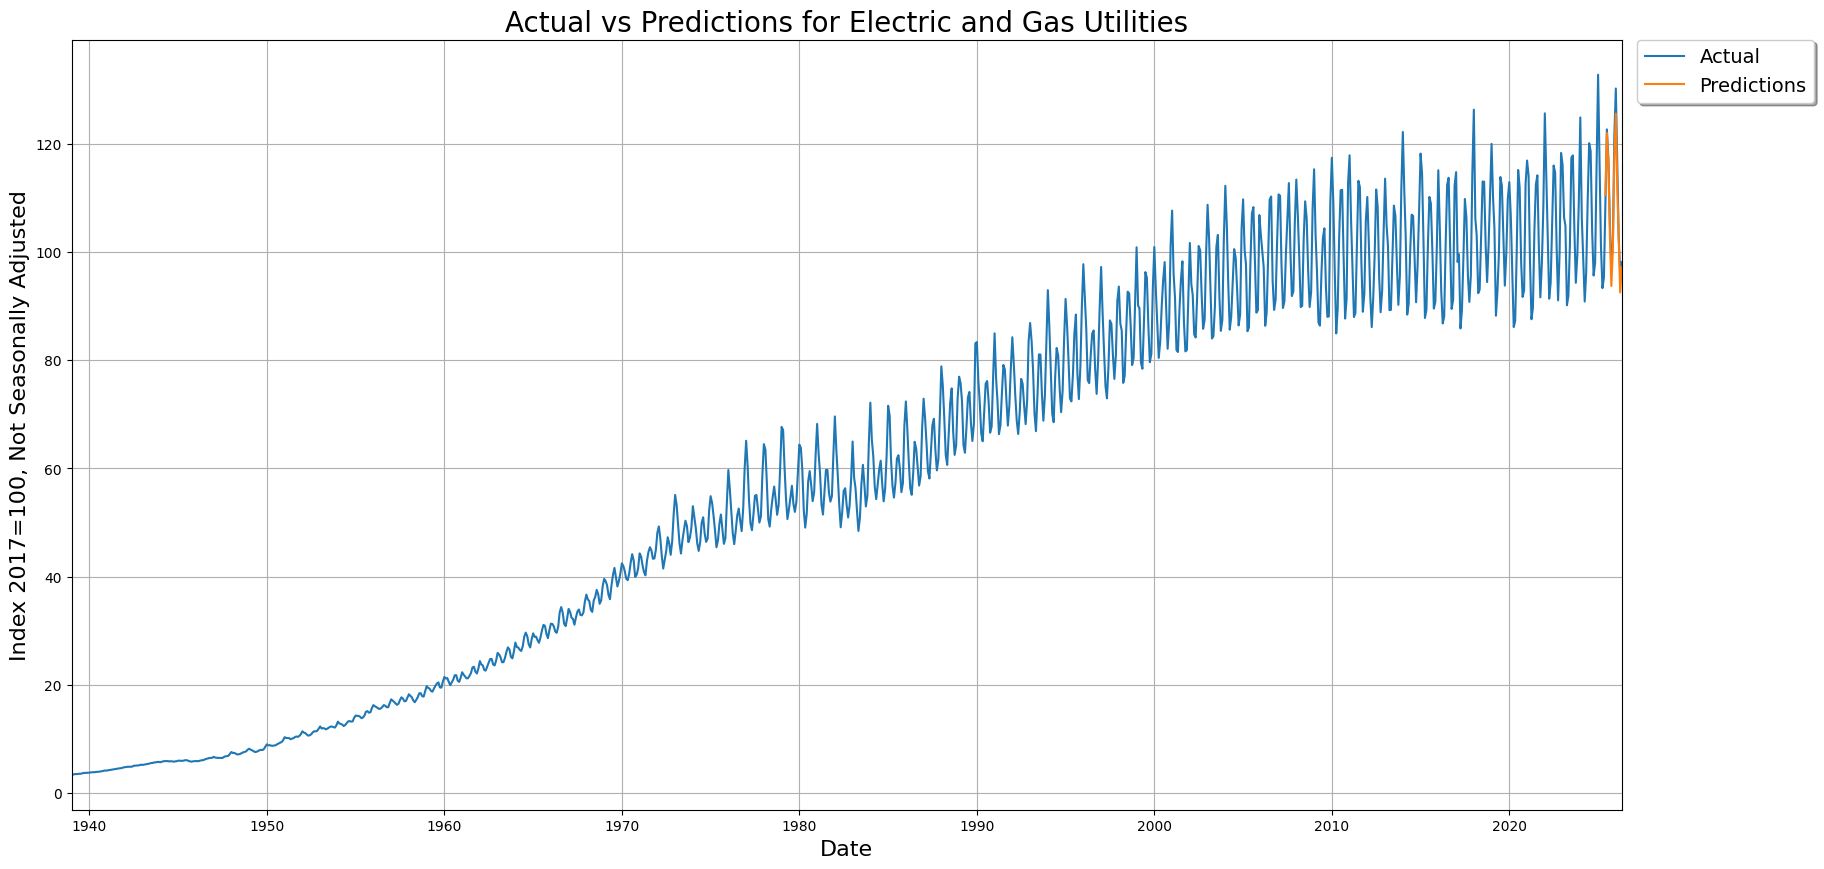

In [208]:
# CODE HERE TO DISPLAY THE END OF THE GRAPH
plt.figure(figsize=(20,10))
plt.title('Actual vs Predictions for Electric and Gas Utilities' , fontsize = 20)
plt.ylabel('Index 2017=100, Not Seasonally Adjusted', fontsize = 16)
plt.xlabel('Date', fontsize = 16)
plt.grid(True)
plt.autoscale(axis='x',tight=True)
plt.plot(df['IPG2211A2N'] , label = 'Actual')
plt.plot(x,true_predictions , label = 'Predictions')
plt.legend(fontsize=14, loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0. , frameon=True , fancybox=True, shadow=True, ncol=1)
plt.show()

In [232]:
true_predictions_1d = true_predictions.reshape(-1)

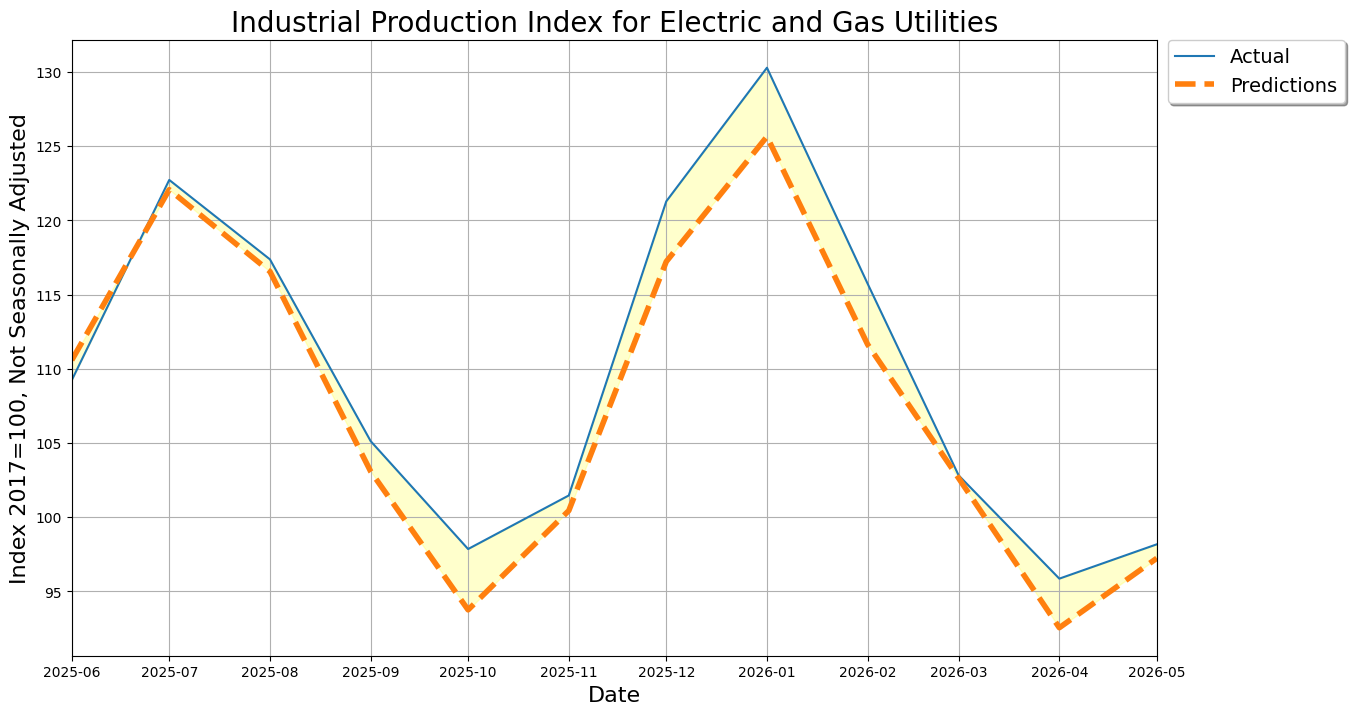

In [238]:
# CODE HERE TO DISPLAY THE END OF THE GRAPH
plt.figure(figsize=(14,8))
plt.title('Industrial Production Index for Electric and Gas Utilities' , fontsize = 20)
plt.ylabel('Index 2017=100, Not Seasonally Adjusted', fontsize = 16)
plt.xlabel('Date', fontsize = 16)
plt.grid(True)
plt.autoscale(axis='x',tight=True)
plt.plot(df['IPG2211A2N'].loc[x] , label = 'Actual')
plt.plot(x, true_predictions , label = 'Predictions', ls='--', lw=4)
plt.fill_between(x, 
                 y1=true_predictions_1d, 
                 y2=df['IPG2211A2N'].loc[x],
                 where=(true_predictions_1d != df['IPG2211A2N'].loc[x]), 
                 interpolate=True,
                 color='yellow', 
                 alpha=0.2)

plt.legend(fontsize=14, 
           loc='upper left', 
           bbox_to_anchor=(1.01, 1), 
           borderaxespad=0. , 
           frameon=True , 
           fancybox=True, 
           shadow=True, 
           ncol=1)
plt.show()

## Great job!